# ☀️ SOLAR POWER FORECASTING - COLLABORATIVE MODEL TRAINING TEMPLATE ☀️

Chào mừng cả nhóm! Đây là Notebook mẫu được chuẩn bị sẵn nhằm giúp **5 thành viên** dễ dàng tích hợp và huấn luyện **5 mô hình khác nhau** của mình vào pipeline dự báo công suất phát điện mặt trời (Inverter-level).

### 📋 Hướng dẫn sử dụng:
1. **Không thay đổi** các phần tiền xử lý dữ liệu, chuẩn hóa (Scaling), xử lý ràng buộc vật lý, và đánh giá hiệu năng để đảm bảo tính công bằng và nhất quán khi so sánh kết quả giữa các thành viên.
2. **Chỉ viết code mô hình của bạn** ở **Mục 3 (Huấn luyện Mô hình của bạn)**.
3. Khi chạy xong, Notebook sẽ tự động áp dụng ràng buộc vật lý ban đêm ($AC\_POWER = 0$), tính toán các độ đo ($R^2$, MAE, RMSE, MAPE), vẽ biểu đồ và lưu mô hình cũng như kết quả báo cáo của bạn vào thư mục `Result/`.

---

## 1. Khai báo thư viện & Thiết lập đường dẫn

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Thiết lập đường dẫn thư mục gốc (Gốc dự án chứa các thư mục datasets, Result, src)
BASE_DIR = Path(".").resolve()
SPLIT_DIR = BASE_DIR / "datasets" / "split"
RESULT_DIR = BASE_DIR / "Result"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# Cấu hình biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6.5)

print("Setup thành công! Sẵn sàng tải dữ liệu.")

Setup thành công! Sẵn sàng tải dữ liệu.


## 2. Tải dữ liệu & Chuẩn hóa đặc trưng (Scaling)
Chúng ta sẽ tải dữ liệu đã được làm sạch, trích chọn đặc trưng và phân chia thời gian (Train: 20 ngày, Val: 7 ngày, Test: 7 ngày) từ thư mục `datasets/split/`.

In [2]:
# 16 Đặc trưng đầu vào hoàn chỉnh của mô hình
FEATURES = [
    "AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION", "Temp_Diff",
    "Hour_Sin", "Hour_Cos", "Day_of_Year_Sin", "Day_of_Year_Cos",
    "IRRADIATION_lag_1", "IRRADIATION_lag_2", "AMBIENT_TEMP_lag_1", "MODULE_TEMP_lag_1",
    "IRRADIATION_roll_mean_1h", "IRRADIATION_roll_std_1h",
    "OM_TEMPERATURE_2M", "OM_RELATIVE_HUMIDITY_2M"
]
TARGET = "AC_POWER"

def load_and_scale_data(plant_no):
    # Đọc dữ liệu phân chia của từng nhà máy
    train_df = pd.read_csv(SPLIT_DIR / f"plant_{plant_no}_train.csv")
    val_df = pd.read_csv(SPLIT_DIR / f"plant_{plant_no}_val.csv")
    test_df = pd.read_csv(SPLIT_DIR / f"plant_{plant_no}_test.csv")
    
    # Lấy các đặc trưng có sẵn trong dữ liệu
    available_features = [col for col in FEATURES if col in train_df.columns]
    
    X_train, y_train = train_df[available_features], train_df[TARGET]
    X_val, y_val = val_df[available_features], val_df[TARGET]
    X_test, y_test = test_df[available_features], test_df[TARGET]
    
    # Khởi tạo và khớp StandardScaler trên tập Train, sau đó transform cho tập Val/Test để tránh rò rỉ dữ liệu
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=available_features)
    X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=available_features)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=available_features)
    
    return X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test, train_df, val_df, test_df, scaler

print("Định nghĩa hàm tải dữ liệu thành công!")

Định nghĩa hàm tải dữ liệu thành công!


## 3. [KHU VỰC HUẤN LUYỆN MÔ HÌNH CỦA BẠN]
**Hướng dẫn dành cho thành viên:**
* Điền tên mô hình của bạn vào biến `MY_MODEL_NAME` (ví dụ: `XGBoost`, `LightGBM`, `SVR`, `Neural Network`, `Gradient Boosting`).
* Khởi tạo mô hình của bạn và lưu vào biến `my_model`.
* Huấn luyện mô hình sử dụng dữ liệu đã chuẩn hóa: `X_train_scaled` và `y_train`.
* Điều chỉnh siêu tham số (Hyperparameters) tại phần này nếu cần.

In [3]:
# =====================================================================
# THÔNG TIN THÀNH VIÊN VÀ MÔ HÌNH
# =====================================================================
MY_MODEL_NAME = "Random_Forest"
MEMBER_NAME = "Nguyen_Van_Tung_Duong"

# Chọn nhà máy để chạy thử nghiệm (Plant 1 hoặc Plant 2)
PLANT_NO = 1

print(f"Thành viên: {MEMBER_NAME} | Mô hình: {MY_MODEL_NAME} | Nhà máy: Plant {PLANT_NO}")

# =====================================================================
# BƯỚC 1: Tải và chuẩn hóa dữ liệu
# =====================================================================
X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test, train_df, val_df, test_df, scaler = load_and_scale_data(PLANT_NO)

print(f"\n📊 Kích thước dữ liệu:")
print(f"   Train:      {X_train_scaled.shape[0]:>6} mẫu  ({X_train_scaled.shape[1]} features)")
print(f"   Validation: {X_val_scaled.shape[0]:>6} mẫu")
print(f"   Test:       {X_test_scaled.shape[0]:>6} mẫu")

# =====================================================================
# BƯỚC 2: Tìm kiếm siêu tham số tối ưu bằng RandomizedSearchCV
# (Chỉ dùng tập Train để huấn luyện, tập Validation để đánh giá)
# TUYỆT ĐỐI KHÔNG dùng tập Test trong bước này!
# =====================================================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score
import numpy as np

print("\n🔍 Bắt đầu tìm kiếm siêu tham số (RandomizedSearchCV)...")
print("   ⚠️  Chỉ sử dụng tập Train để cross-validate, KHÔNG dùng Test!")

# Không gian tham số cần tìm kiếm
param_distributions = {
    'n_estimators':      [100, 200, 300, 400, 500],
    'max_depth':         [8, 10, 12, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5, 0.7],
    'bootstrap':         [True, False]
}

# Khởi tạo mô hình nền tảng
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# RandomizedSearchCV: chỉ sample một số tổ hợp ngẫu nhiên → nhanh hơn GridSearch
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_distributions,
    n_iter=30,              # Thử 30 tổ hợp ngẫu nhiên
    cv=5,                   # 5-fold cross-validation trên tập Train
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_scaled, y_train)

print(f"\n✅ Tìm kiếm hoàn tất!")
print(f"   Best CV R² (5-fold trên Train): {random_search.best_score_:.4f}")
print(f"   Bộ tham số tối ưu: {random_search.best_params_}")

# Đánh giá nhanh trên Validation để xác nhận (KHÔNG dùng để chọn tham số)
best_rf = random_search.best_estimator_
val_r2_quick = r2_score(y_val, best_rf.predict(X_val_scaled))
print(f"   R² trên Validation (xác nhận):  {val_r2_quick:.4f}")

# =====================================================================
# BƯỚC 3: Gán mô hình tốt nhất vào biến my_model
# =====================================================================
my_model = random_search.best_estimator_

print(f"\n🌲 Mô hình Random Forest đã được chọn:")
print(f"   n_estimators      = {my_model.n_estimators}")
print(f"   max_depth         = {my_model.max_depth}")
print(f"   min_samples_split = {my_model.min_samples_split}")
print(f"   min_samples_leaf  = {my_model.min_samples_leaf}")
print(f"   max_features      = {my_model.max_features}")
print(f"   bootstrap         = {my_model.bootstrap}")

# =====================================================================
# BƯỚC 4: Top 10 đặc trưng quan trọng nhất (Feature Importance)
# =====================================================================
feature_names = X_train_scaled.columns.tolist()
importances = my_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

print(f"\n📌 Top 10 đặc trưng quan trọng nhất (Feature Importance):")
for rank, i in enumerate(sorted_idx[:10], 1):
    bar = "█" * int(importances[i] * 100)
    print(f"   {rank:>2}. {feature_names[i]:<35} {importances[i]:.4f}  {bar}")

print("\n✅ Huấn luyện hoàn tất — sẵn sàng cho bước đánh giá!")


Thành viên: Nguyen_Van_Tung_Duong | Mô hình: Random_Forest | Nhà máy: Plant 1

📊 Kích thước dữ liệu:
   Train:       39406 mẫu  (16 features)
   Validation:  14632 mẫu
   Test:        14740 mẫu

🔍 Bắt đầu tìm kiếm siêu tham số (RandomizedSearchCV)...
   ⚠️  Chỉ sử dụng tập Train để cross-validate, KHÔNG dùng Test!
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Tìm kiếm hoàn tất!
   Best CV R² (5-fold trên Train): 0.9866
   Bộ tham số tối ưu: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 10, 'bootstrap': True}
   R² trên Validation (xác nhận):  0.9677

🌲 Mô hình Random Forest đã được chọn:
   n_estimators      = 100
   max_depth         = 10
   min_samples_split = 5
   min_samples_leaf  = 4
   max_features      = 0.7
   bootstrap         = True

📌 Top 10 đặc trưng quan trọng nhất (Feature Importance):
    1. IRRADIATION                         0.7629  ██████████████████████████████████████████████████████████████

## 4. Áp dụng Ràng buộc Vật lý & Đánh giá Hiệu năng (Độ đo Học thuật)
Mô hình sẽ tự động áp dụng ràng buộc vật lý hậu dự báo:
* **Ban đêm (is_day == 0):** Cường bức công suất phát điện bằng $0.0\text{ kW}$.
* **Công suất âm:** Giới hạn dưới cắt cụt về $0.0\text{ kW}$ (vì công suất thực tế không thể âm).

Các độ đo đánh giá khoa học bao gồm:
1. **$R^2$ Score (Hệ số xác định):** Càng gần 1 càng tốt.
2. **MAE (Sai số tuyệt đối trung bình):** Đo bằng kW.
3. **RMSE (Căn sai số bình phương trung bình):** Đo bằng kW.
4. **Daytime MAPE (Sai số phần trăm tuyệt đối trung bình ban ngày):** Tính trên các mốc thời gian ban ngày ($y_{true} > 5\text{ kW}$) để tránh lỗi chia cho 0 vào ban đêm.

In [4]:
def evaluate_predictions(y_true, y_pred_raw, df_split):
    y_pred = y_pred_raw.copy()
    
    # Ràng buộc vật lý 1: Ban đêm (is_day == 0) thì công suất bắt buộc bằng 0
    y_pred[df_split["is_day"] == 0] = 0.0
    
    # Ràng buộc vật lý 2: Giới hạn dưới không âm
    y_pred = np.clip(y_pred, a_min=0, a_max=None)
    
    # Tính toán các độ đo
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Tính toán MAPE chỉ trong thời gian ban ngày (y_true > 5 kW) để tránh lỗi chia cho 0
    daylight_mask = y_true > 5.0
    mape = np.mean(np.abs((y_true[daylight_mask] - y_pred[daylight_mask]) / y_true[daylight_mask])) * 100 if daylight_mask.sum() > 0 else 0.0
    
    return {
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "predictions": y_pred
    }

# Dự báo thử nghiệm trên tập Validation và Test
y_val_pred_raw = my_model.predict(X_val_scaled)
y_test_pred_raw = my_model.predict(X_test_scaled)

val_metrics = evaluate_predictions(y_val, y_val_pred_raw, val_df)
test_metrics = evaluate_predictions(y_test, y_test_pred_raw, test_df)

# In kết quả dạng bảng đẹp mắt lên màn hình
print("\n" + "="*80)
print(f" KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: {MY_MODEL_NAME.upper()} (PLANT {PLANT_NO})")
print("="*80)
print(f"{'Tập dữ liệu':<15} | {'R2 Score':<10} | {'MAE (kW)':<10} | {'RMSE (kW)':<11} | {'MAPE (Ban ngày %)'}")
print("-"*80)
print(f"{'Validation':<15} | {val_metrics['R2']:<10.4f} | {val_metrics['MAE']:<10.2f} | {val_metrics['RMSE']:<11.2f} | {val_metrics['MAPE']:.2f}%")
print(f"{'Test (Holdout)':<15} | {test_metrics['R2']:<10.4f} | {test_metrics['MAE']:<10.2f} | {test_metrics['RMSE']:<11.2f} | {test_metrics['MAPE']:.2f}%")
print("="*80)


 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: RANDOM_FOREST (PLANT 1)
Tập dữ liệu     | R2 Score   | MAE (kW)   | RMSE (kW)   | MAPE (Ban ngày %)
--------------------------------------------------------------------------------
Validation      | 0.9677     | 25.45      | 72.42       | 8.69%
Test (Holdout)  | 0.9804     | 16.42      | 50.29       | 6.23%


## 5. Trực quan hóa kết quả dự báo (Actual vs. Predicted 3 ngày tập Test)
Mô hình sẽ tự động trích xuất chuỗi thời gian 3 ngày đầu tiên của tập kiểm thử của inverter mẫu đầu tiên để vẽ đồ thị so sánh giữa công suất thực tế (`Actual`) và dự báo của mô hình của bạn (`Predicted`).

Đã vẽ và lưu đồ thị thực tế vs dự báo tại: Result/plant_1_random_forest_actual_vs_predicted.png


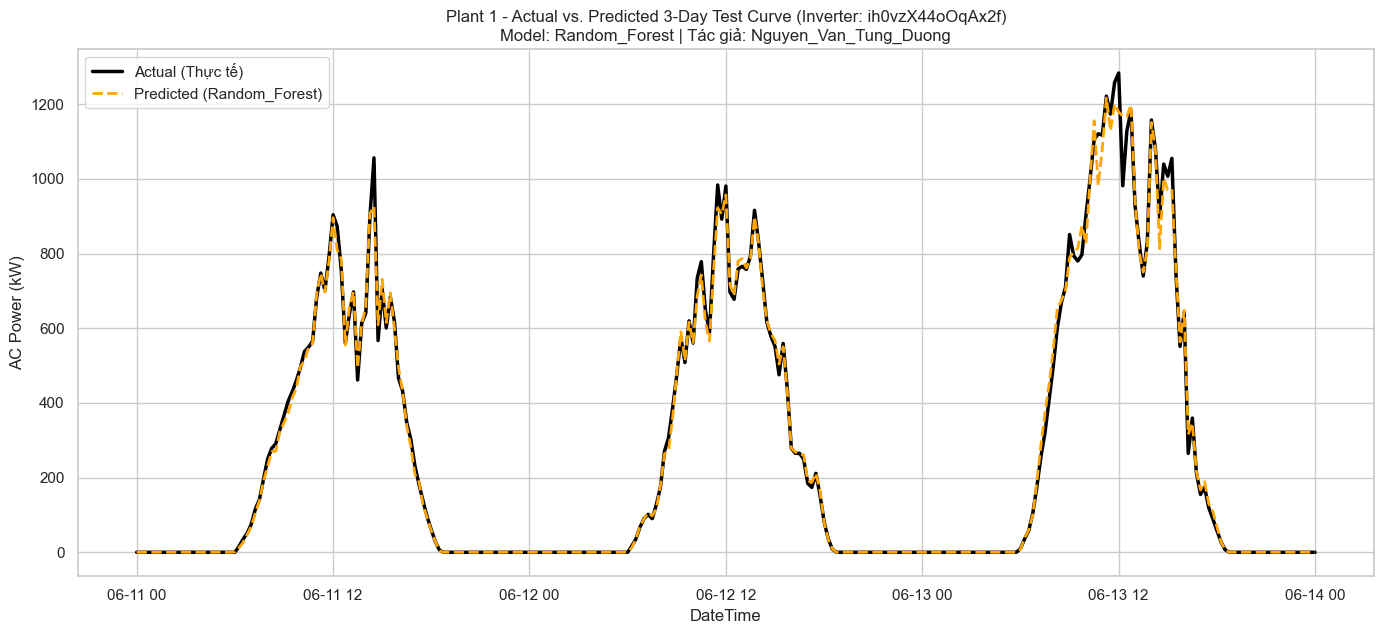

In [5]:
# Trích xuất dữ liệu inverter mẫu đầu tiên để vẽ đồ thị
test_df["DATE_TIME"] = pd.to_datetime(test_df["DATE_TIME"])
sample_inverter = test_df["SOURCE_KEY"].iloc[0]
sample_mask = test_df["SOURCE_KEY"] == sample_inverter

plot_df = test_df[sample_mask].sort_values(by="DATE_TIME")
start_date = plot_df["DATE_TIME"].min()
end_date = start_date + pd.Timedelta(days=3)
plot_subset = plot_df[(plot_df["DATE_TIME"] >= start_date) & (plot_df["DATE_TIME"] <= end_date)]

# Lọc dự báo tương ứng
y_test_pred = test_metrics["predictions"]
pred_series = pd.Series(y_test_pred, index=test_df.index)
sample_pred_subset = pred_series[sample_mask][(plot_df["DATE_TIME"] >= start_date) & (plot_df["DATE_TIME"] <= end_date)]

plt.figure(figsize=(14, 6.5))
plt.plot(plot_subset["DATE_TIME"], plot_subset["AC_POWER"], label="Actual (Thực tế)", color="black", linewidth=2.5)
plt.plot(plot_subset["DATE_TIME"], sample_pred_subset, label=f"Predicted ({MY_MODEL_NAME})", color="orange", linewidth=2, linestyle="--")

plt.title(f"Plant {PLANT_NO} - Actual vs. Predicted 3-Day Test Curve (Inverter: {sample_inverter})\nModel: {MY_MODEL_NAME} | Tác giả: {MEMBER_NAME}")
plt.xlabel("DateTime")
plt.ylabel("AC Power (kW)")
plt.legend()
plt.tight_layout()

# Lưu đồ thị vào Result/
plot_filename = f"plant_{PLANT_NO}_{MY_MODEL_NAME.lower().replace(' ', '_')}_actual_vs_predicted.png"
plt.savefig(RESULT_DIR / plot_filename, dpi=150)
print(f"Đã vẽ và lưu đồ thị thực tế vs dự báo tại: Result/{plot_filename}")
plt.show()

## 6. Lưu mô hình & Xuất báo cáo điểm số tự động
Đoạn mã dưới sẽ:
1. Lưu đối tượng mô hình của bạn dưới dạng file `.pkl` để sau này tích hợp vào mô hình chính.
2. Ghi kết quả điểm số vào file tổng hợp chung `Result/metrics_report.csv` để nhóm trưởng dễ dàng gom kết quả của 5 thành viên lại so sánh.

In [6]:
# 1. Lưu file model pickle
model_filename = f"plant_{PLANT_NO}_{MY_MODEL_NAME.lower().replace(' ', '_')}.pkl"
with open(RESULT_DIR / model_filename, "wb") as f:
    pickle.dump(my_model, f)
print(f"1. Đã lưu đối tượng mô hình thành công tại: Result/{model_filename}")

# 2. Ghi kết quả vào file report CSV dùng chung
report_csv_path = RESULT_DIR / "metrics_report.csv"

# Chuẩn bị dòng kết quả mới
new_row = {
    "Plant": f"Plant {PLANT_NO}",
    "Model": MY_MODEL_NAME,
    "Author": MEMBER_NAME,
    "Val_R2": val_metrics["R2"],
    "Val_MAE": val_metrics["MAE"],
    "Val_RMSE": val_metrics["RMSE"],
    "Val_MAPE": val_metrics["MAPE"],
    "Test_R2": test_metrics["R2"],
    "Test_MAE": test_metrics["MAE"],
    "Test_RMSE": test_metrics["RMSE"],
    "Test_MAPE": test_metrics["MAPE"]
}

# Đọc file cũ nếu đã tồn tại hoặc tạo mới
if report_csv_path.exists():
    try:
        report_df = pd.read_csv(report_csv_path)
    except Exception:
        report_df = pd.DataFrame()
else:
    report_df = pd.DataFrame()

# Gộp dòng mới vào report chung
new_df = pd.DataFrame([new_row])
if not report_df.empty:
    # Xóa dòng cũ nếu trùng tên mô hình và nhà máy để tránh trùng lặp
    if "Model" in report_df.columns and "Plant" in report_df.columns:
        mask = (report_df["Plant"] == f"Plant {PLANT_NO}") & (report_df["Model"] == MY_MODEL_NAME)
        report_df = report_df[~mask]
    report_df = pd.concat([report_df, new_df], ignore_index=True)
else:
    report_df = new_df

# Xuất lại file CSV
report_df.to_csv(report_csv_path, index=False)
print(f"2. Đã cập nhật kết quả của bạn vào bảng điểm số chung tại: Result/metrics_report.csv!")

# Hiển thị bảng tổng sắp hiện tại
print("\n--- BẢNG ĐIỂM SỐ TỔNG HỢP HIỆN TẠI TRONG RESULT/ ---")
if hasattr(report_df, "style"):
    # Tạo định dạng số cho dễ nhìn trong notebook
    display(report_df.style.format({
        "Val_R2": "{:.4f}", "Val_MAE": "{:.2f}", "Val_RMSE": "{:.2f}", "Val_MAPE": "{:.2f}%",
        "Test_R2": "{:.4f}", "Test_MAE": "{:.2f}", "Test_RMSE": "{:.2f}", "Test_MAPE": "{:.2f}%"
    }))
else:
    display(report_df)


1. Đã lưu đối tượng mô hình thành công tại: Result/plant_1_random_forest.pkl
2. Đã cập nhật kết quả của bạn vào bảng điểm số chung tại: Result/metrics_report.csv!

--- BẢNG ĐIỂM SỐ TỔNG HỢP HIỆN TẠI TRONG RESULT/ ---


ImportError: Missing optional dependency 'Jinja2'. DataFrame.style requires jinja2. Use pip or conda to install Jinja2.